In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# This loads your file into the memory
# Make sure the filename matches exactly what you uploaded
df = pd.read_csv('/content/Ecommerce_Sales_Data_2024_2025.csv')

print("Setup Complete! Data is loaded.")

Setup Complete! Data is loaded.


In [3]:
# This shows the first 5 rows of your table
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [4]:
# Converting 'Order Date' to a proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Checking for any missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64


In [5]:
# This gives you the Mean, Median, Min, and Max for all numeric columns
df.describe()

,Order ID,Order Date,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2024-09-30 18:58:27.840000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
min,10001.000000,2023-10-04 00:00:00,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2024-04-05 00:00:00,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,2024-09-29 00:00:00,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,2025-03-30 00:00:00,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,2025-10-03 00:00:00,5.000000,79998.000000,20.000000,398485.000000,89688.440000
std,1443.520003,NaN,1.413133,22831.783946,7.084662,85108.208202,14897.684916


/tmp/ipykernel_422/18736962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='viridis')


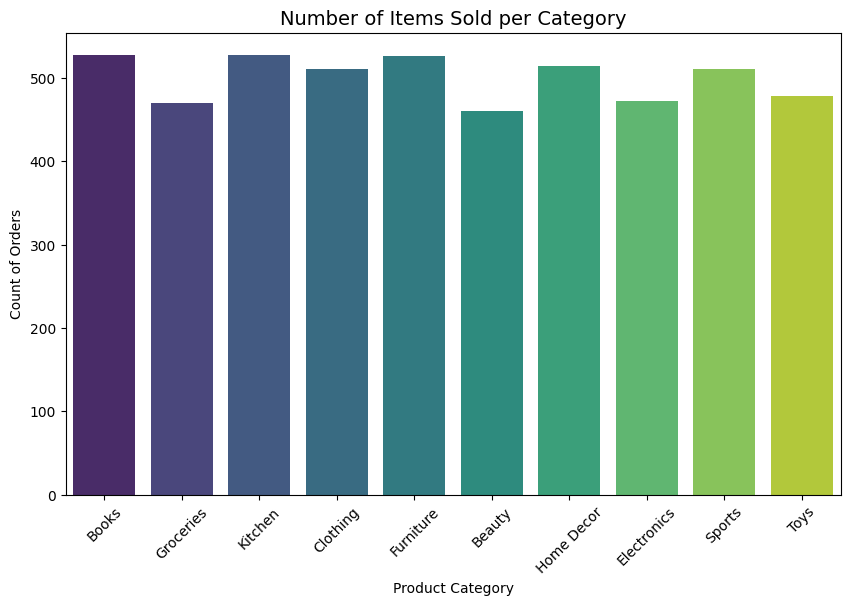

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category', data=df, palette='viridis')
plt.title('Number of Items Sold per Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Count of Orders')
plt.xticks(rotation=45)
plt.show()

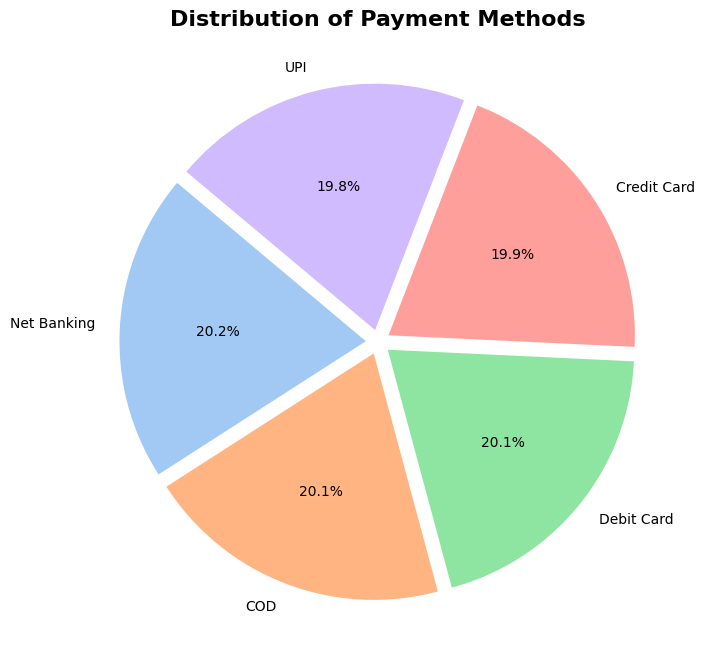

In [7]:
plt.figure(figsize=(8, 8))

# Counting how many people used each payment method
payment_counts = df['Payment Mode'].value_counts()

# Creating the Pie Chart
plt.pie(payment_counts,
        labels=payment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'),
        explode=[0.05] * len(payment_counts)) # This 'pops out' the slices slightly

plt.title('Distribution of Payment Methods', fontsize=16, fontweight='bold')
plt.show()

/tmp/ipykernel_422/3908692645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', palette='magma', order=df['Region'].value_counts().index)


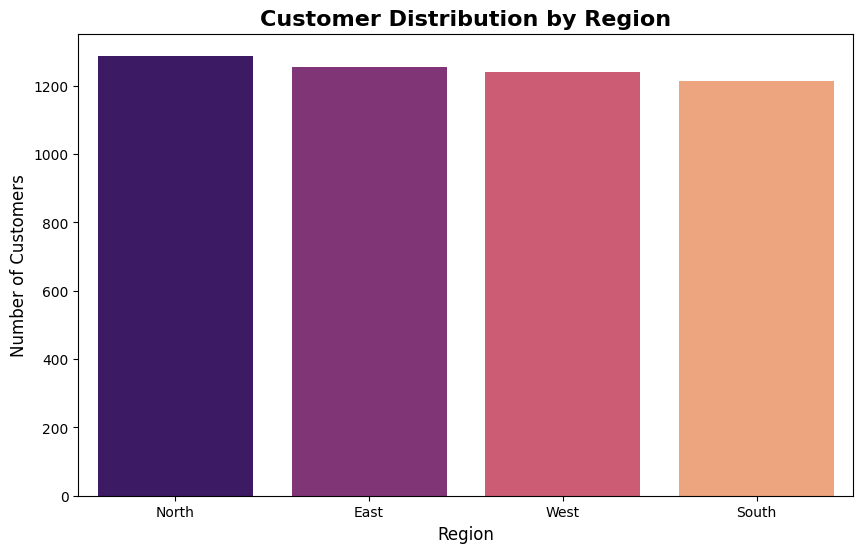

In [8]:
plt.figure(figsize=(10, 6))

# Counting customers in each Region
sns.countplot(data=df, x='Region', palette='magma', order=df['Region'].value_counts().index)

plt.title('Customer Distribution by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

/tmp/ipykernel_422/90834388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='coolwarm')


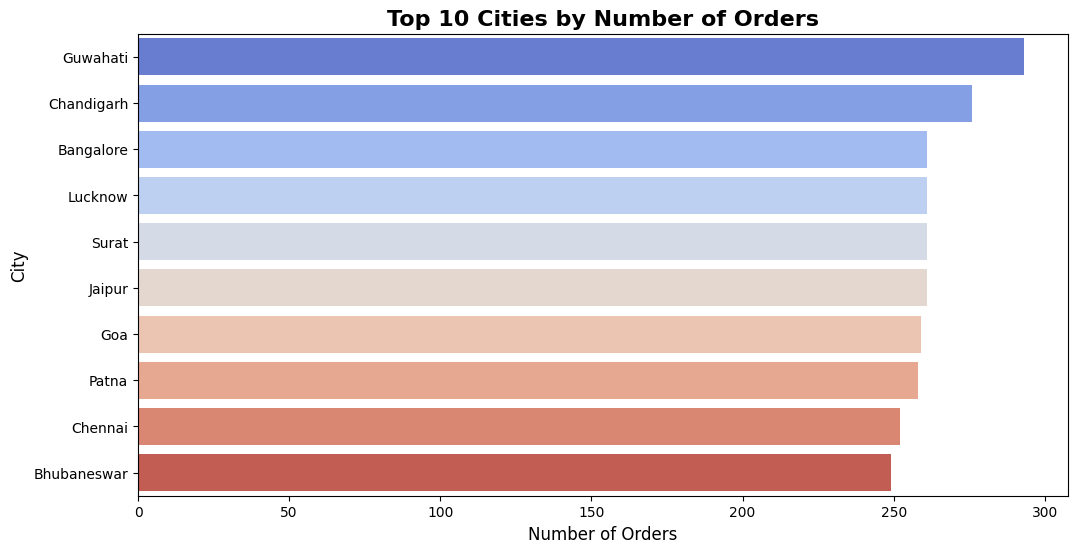

In [9]:
plt.figure(figsize=(12, 6))

# Getting the top 10 cities with the most orders
top_10_cities = df['City'].value_counts().head(10)

sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='coolwarm')

plt.title('Top 10 Cities by Number of Orders', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.show()

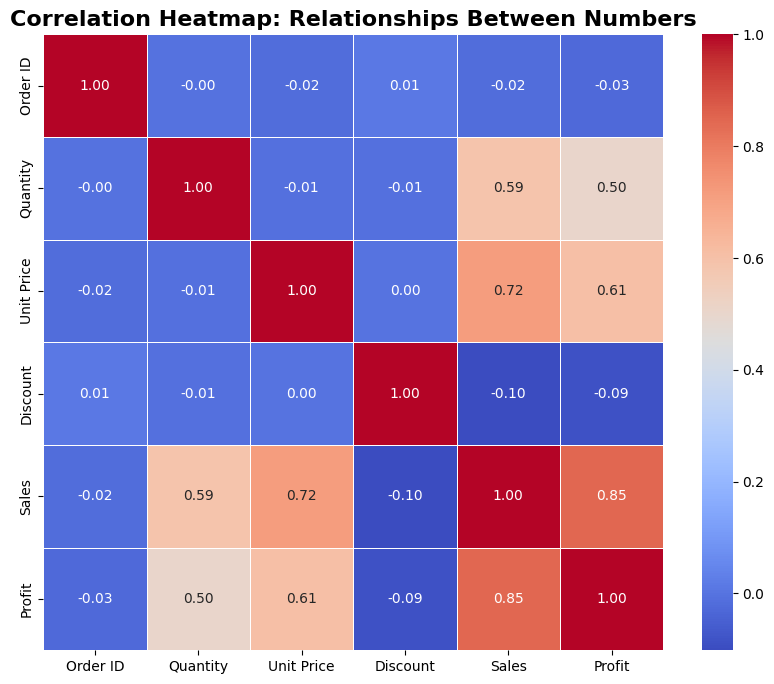

In [10]:
plt.figure(figsize=(10, 8))

# Selecting only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Creating the Heatmap
# annot=True shows the numbers, cmap='coolwarm' gives the red/blue colors
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap: Relationships Between Numbers', fontsize=16, fontweight='bold')
plt.show()

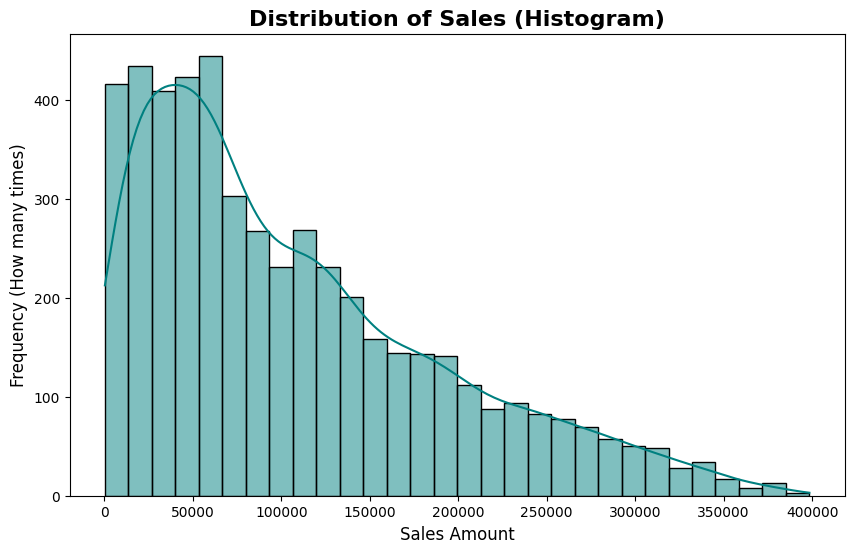

In [11]:
plt.figure(figsize=(10, 6))

# Creating a Histogram for Sales
sns.histplot(df['Sales'], bins=30, kde=True, color='teal')

plt.title('Distribution of Sales (Histogram)', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount', fontsize=12)
plt.ylabel('Frequency (How many times)', fontsize=12)
plt.show()

/tmp/ipykernel_422/1456983711.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')


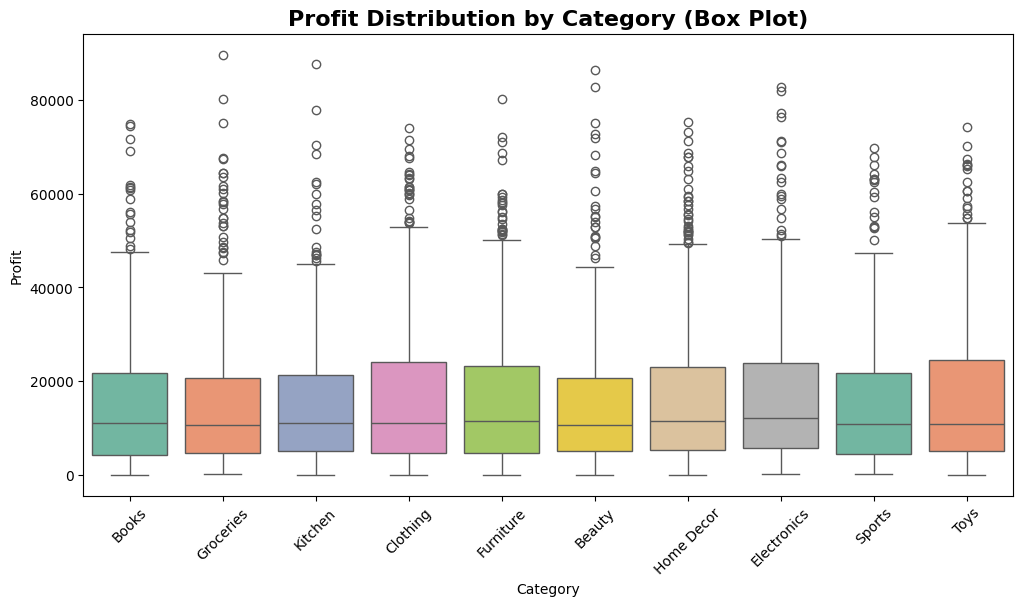

In [12]:
plt.figure(figsize=(12, 6))

# Creating a Box Plot for Profit across Categories
sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')

plt.title('Profit Distribution by Category (Box Plot)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

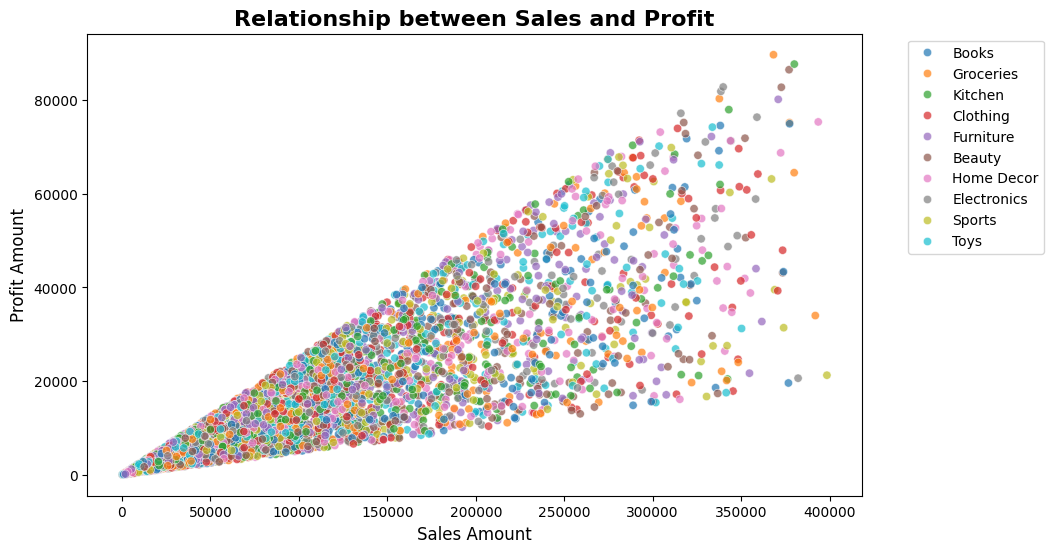

In [13]:
plt.figure(figsize=(10, 6))

# Creating the Scatter Plot
# 'hue' colors the dots by Category to make it look advanced
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.7)

plt.title('Relationship between Sales and Profit', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount', fontsize=12)
plt.ylabel('Profit Amount', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # This moves the legend outside the graph
plt.show()

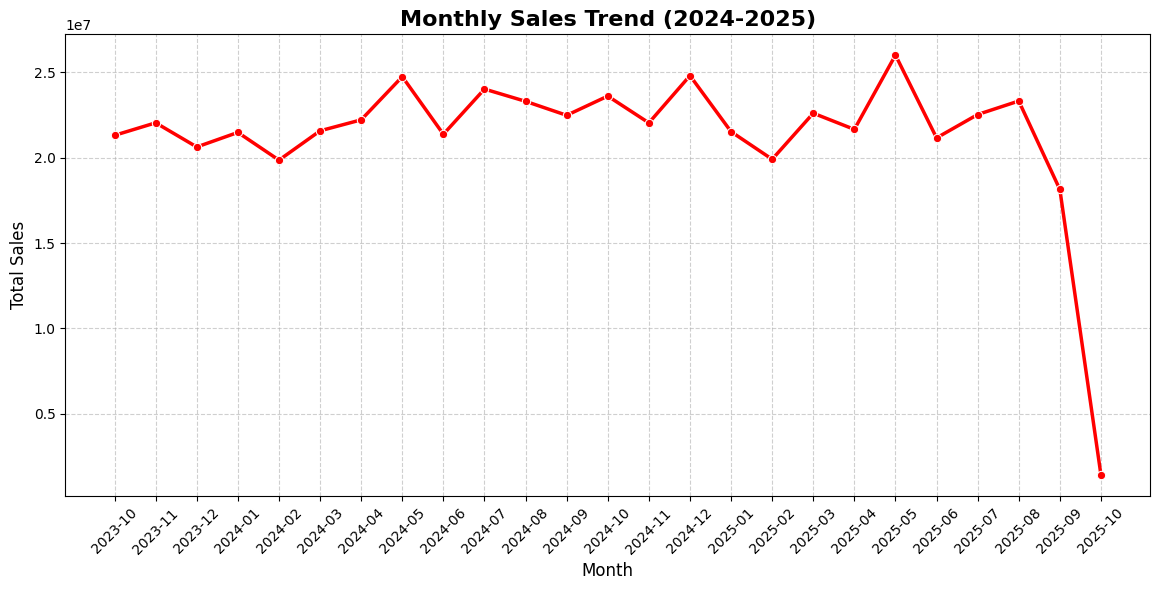

In [14]:
plt.figure(figsize=(14, 6))

# We group the data by Month to see the trend
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Month_Year')['Sales'].sum().reset_index()

# Creating the Line Plot
sns.lineplot(data=monthly_trend, x='Month_Year', y='Sales', marker='o', color='red', linewidth=2.5)

plt.title('Monthly Sales Trend (2024-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

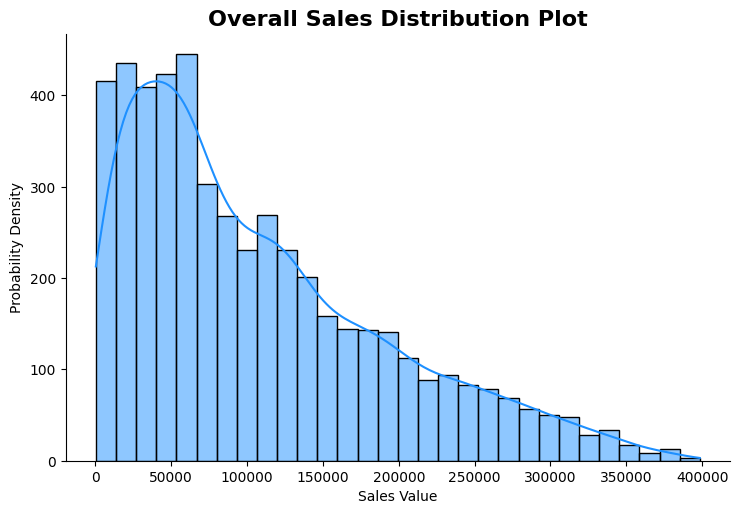

In [15]:
# This is the dedicated Distribution Plot
sns.displot(df['Sales'], color="dodgerblue", kde=True, aspect=1.5)

plt.title('Overall Sales Distribution Plot', fontsize=16, fontweight='bold')
plt.xlabel('Sales Value')
plt.ylabel('Probability Density')
plt.show()

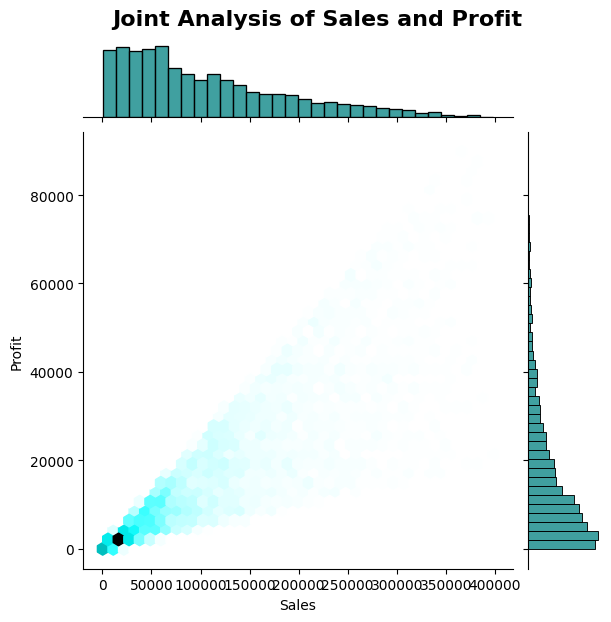

In [16]:
# Joint Plot: Shows relationship AND distribution in one frame
sns.jointplot(data=df, x='Sales', y='Profit', kind='hex', color='teal')
plt.suptitle('Joint Analysis of Sales and Profit', y=1.03, fontsize=16, fontweight='bold')
plt.show()

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

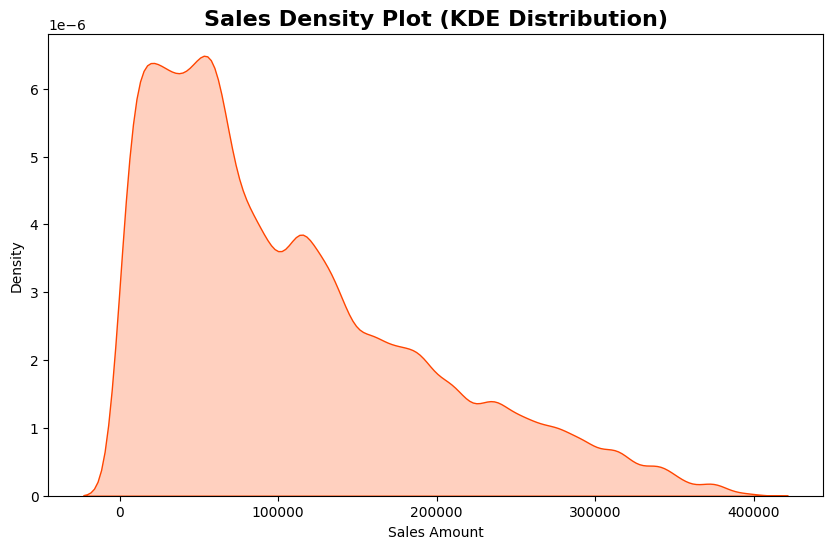

In [18]:
plt.figure(figsize=(10, 6))

# This is the modern version of a Dist Plot
sns.kdeplot(data=df, x='Sales', fill=True, color="orangered", bw_adjust=.5)

plt.title('Sales Density Plot (KDE Distribution)', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount')
plt.ylabel('Density')
plt.show()

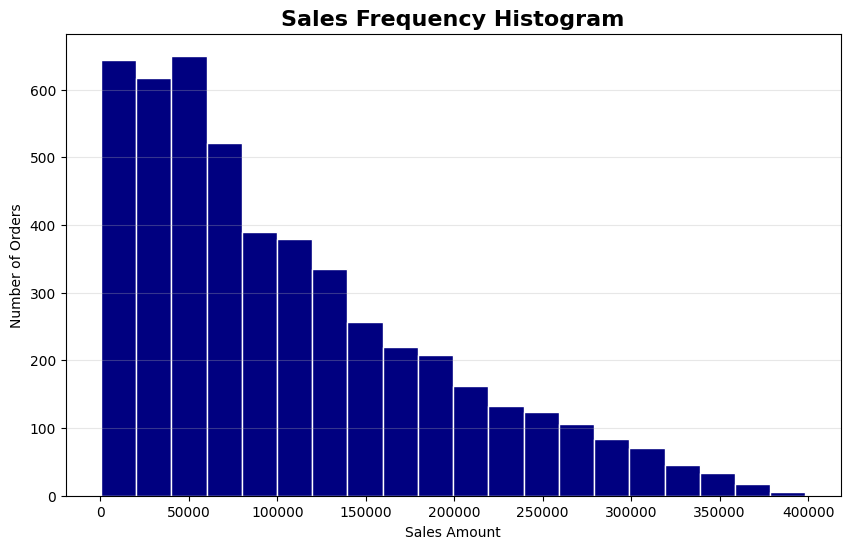

In [19]:
plt.figure(figsize=(10, 6))

# A pure Histogram with 20 bins for clear data grouping
# color='navy' makes it look very professional
plt.hist(df['Sales'], bins=20, color='navy', edgecolor='white')

plt.title('Sales Frequency Histogram', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Orders')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [20]:
# This creates a summary table (Pivot Table)
category_summary = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Total Orders'}).sort_values(by='Profit', ascending=False)

# Display the summary table
print("--- Category-wise Performance Summary ---")
category_summary

--- Category-wise Performance Summary ---


,Sales,Profit,Quantity,Total Orders
Category,,,,
Furniture,56647187.90,8693087.03,1591,527
Home Decor,57233222.35,8556846.94,1539,515
Clothing,55053908.30,8445750.29,1513,511
Books,54932643.00,8076273.29,1571,528
Electronics,52587883.95,8042133.88,1426,472
Toys,52227366.45,7986871.44,1475,478
Kitchen,54227902.30,7879573.29,1544,528
Sports,52069397.25,7739430.04,1489,511
Beauty,50803409.70,7213436.07,1395,460


In [21]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


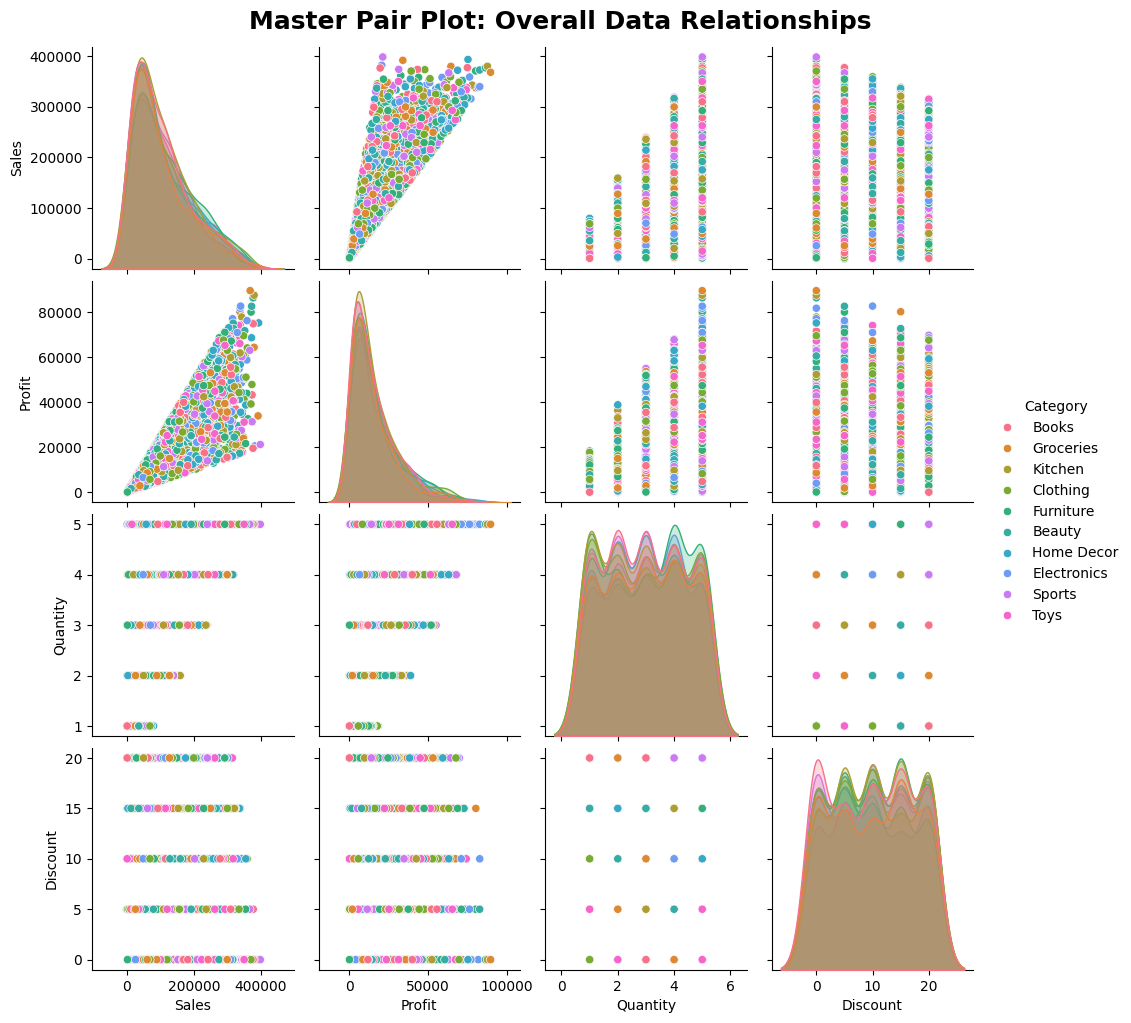

In [22]:
#PairPlot
# This creates a matrix of scatter plots and histograms
# It is the ultimate visualization for Exploratory Data Analysis (EDA)
sns.pairplot(df[['Sales', 'Profit', 'Quantity', 'Discount', 'Category']], hue='Category', palette='husl')

plt.suptitle('Master Pair Plot: Overall Data Relationships', y=1.02, fontsize=18, fontweight='bold')
plt.show()